In [1]:
import ast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../data/experiments_results.csv")
df["fitness_history"] = df["fitness_history"].apply(ast.literal_eval)
df.head()

,dimension,benchmark,algorithm,best_fitness,best_position,fitness_history,execution_time
0,100,Ackley,PSO (JAX),19.393826,"[-6.029745578765869, -12.969038963317871, 7.98...","[20.823354721069336, 20.823354721069336, 20.82...",0.104375
1,100,Griewank,PSO (JAX),183.288620,"[-4.753912448883057, -9.357246398925781, 35.84...","[1768.9271240234375, 1768.9271240234375, 1768....",0.116010
2,100,Levy,PSO (JAX),122.371742,"[-4.256669044494629, 0.9209789633750916, 3.648...","[858.598388671875, 858.598388671875, 858.59838...",0.097319
3,100,Rastrigin,PSO (JAX),778.719971,"[0.9842090606689453, 1.0042542219161987, -3.93...","[1515.945556640625, 1515.945556640625, 1515.94...",0.095932
4,100,Rosenbrock,PSO (JAX),607010.875000,"[-0.17230312526226044, -5.0, 2.222995281219482...","[6219944.5, 6219944.5, 6219944.5, 5480734.0, 5...",0.090814


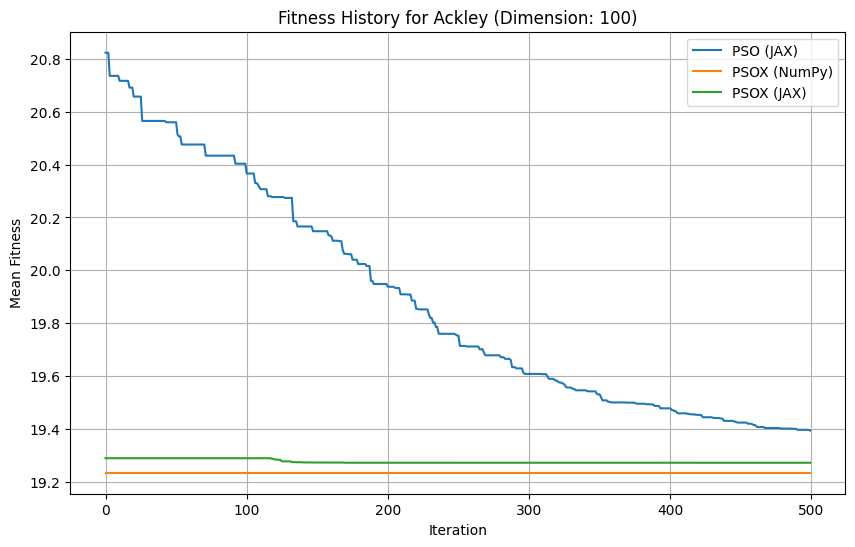

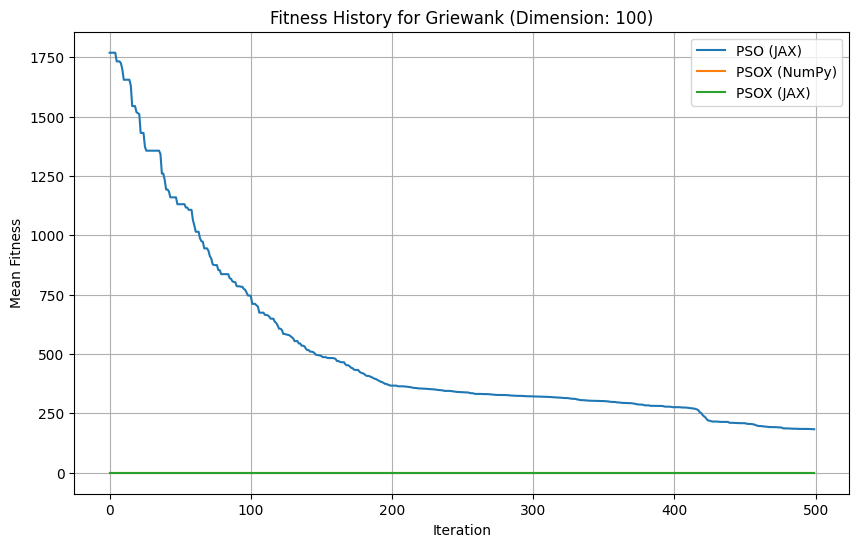

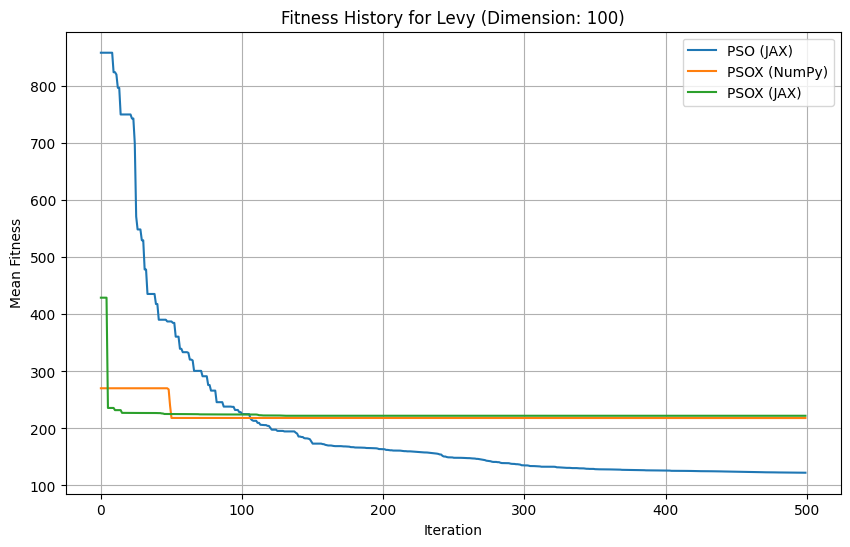

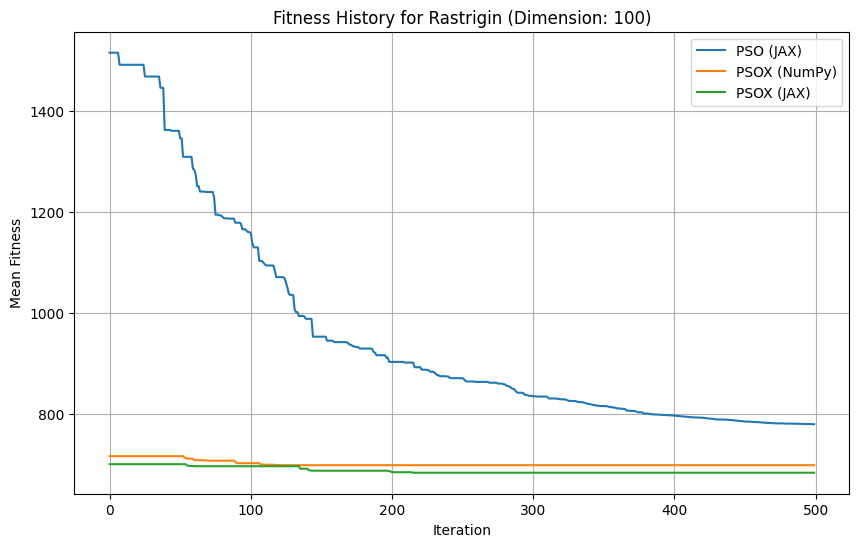

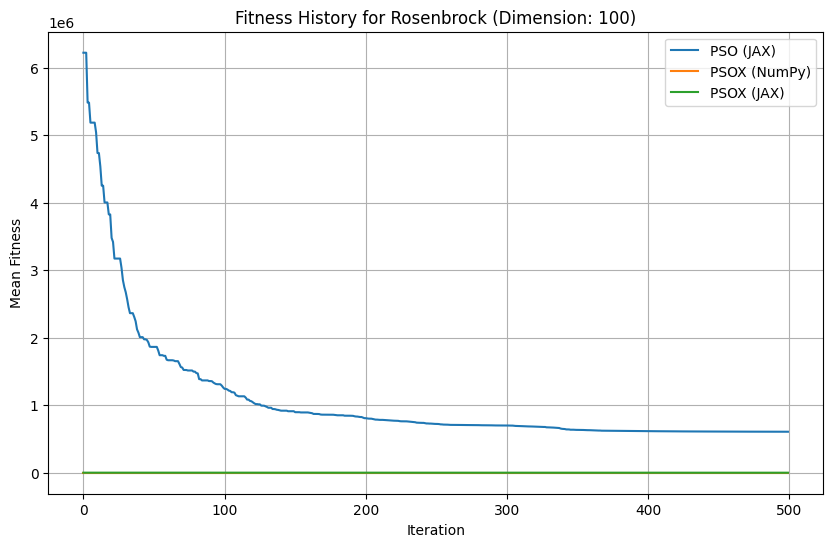

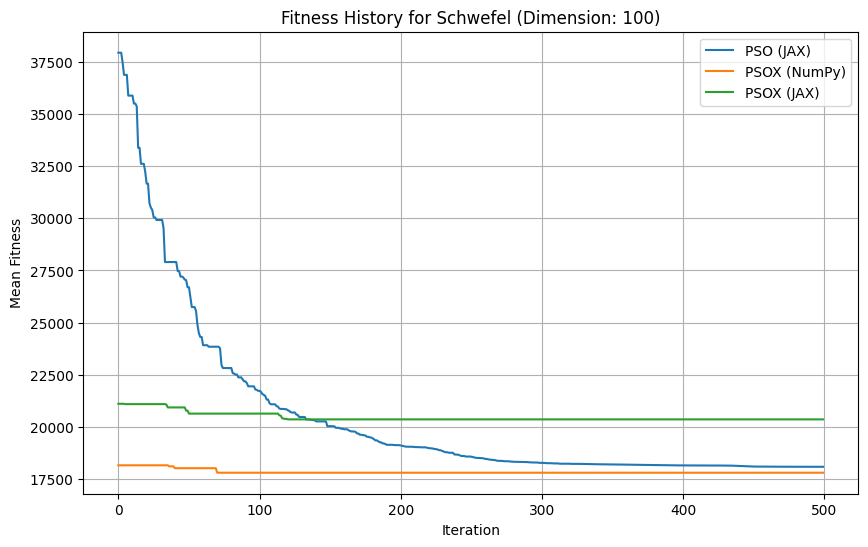

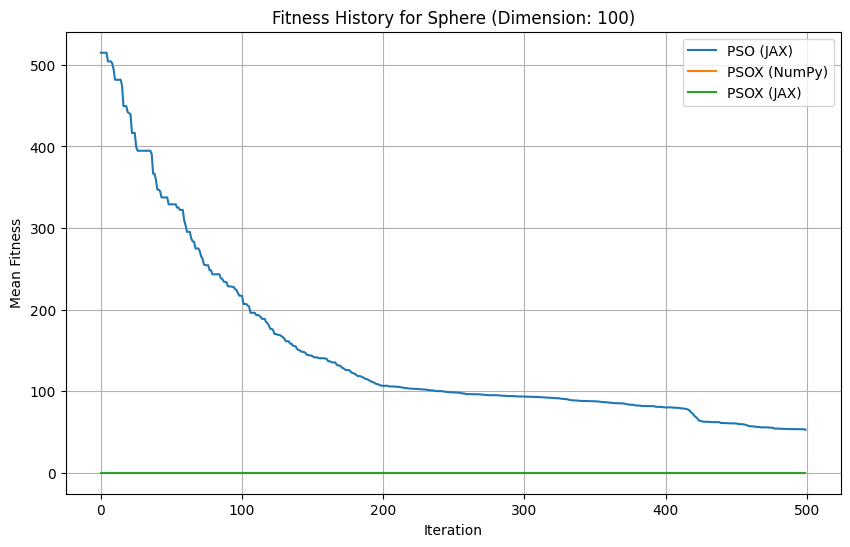

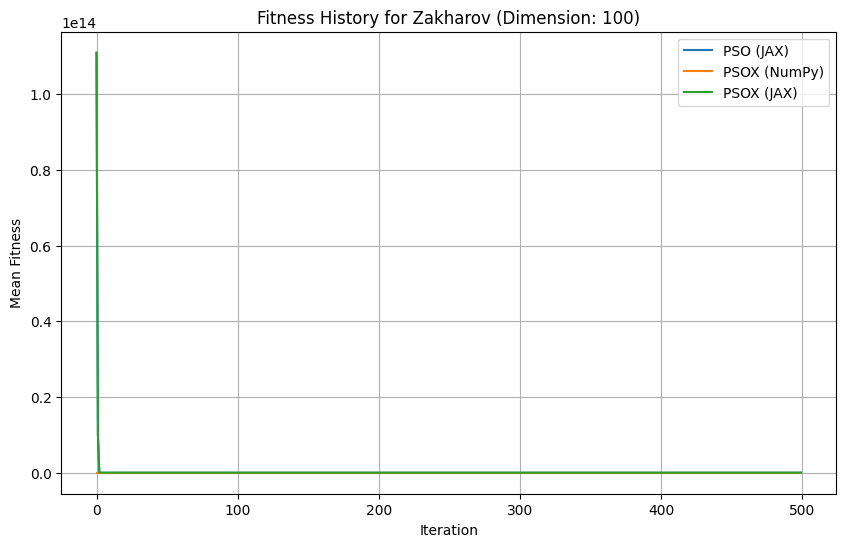

In [3]:
for dimension in df["dimension"].unique():
    for benchmark in df["benchmark"].unique():
        subset = df[(df["dimension"] == dimension) & (df["benchmark"] == benchmark)]
        plt.figure(figsize=(10, 6))
        for algorithm in subset["algorithm"].unique():
            alg_subset = subset[subset["algorithm"] == algorithm]
            fitness_histories = alg_subset["fitness_history"].tolist()
            mean_fitness = pd.DataFrame(fitness_histories).mean()
            plt.plot(mean_fitness, label=algorithm)
        plt.title(f"Fitness History for {benchmark} (Dimension: {dimension})")
        plt.xlabel("Iteration")
        plt.ylabel("Mean Fitness")
        plt.legend()
        plt.grid()
        plt.show()

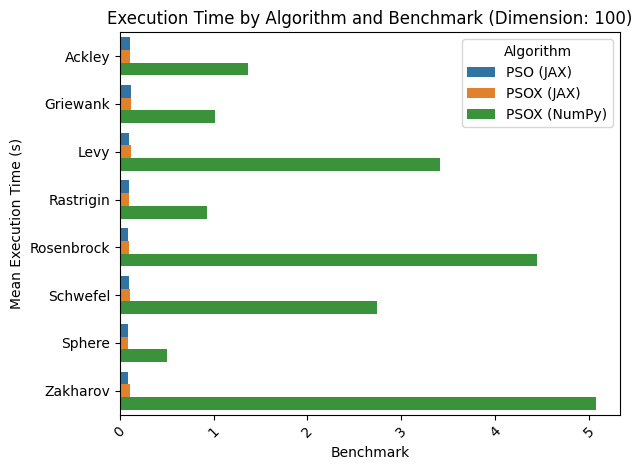

In [4]:
for dimension in df["dimension"].unique():
    mean = (
        df[df["dimension"] == dimension]
        .groupby(["benchmark", "algorithm"])["execution_time"]
        .mean()
    )

    sns.barplot(
        x=mean.values,
        y=mean.index.get_level_values("benchmark"),
        hue=mean.index.get_level_values("algorithm"),
        orient="h",
    )
    plt.title(f"Execution Time by Algorithm and Benchmark (Dimension: {dimension})")
    plt.xlabel("Benchmark")
    plt.ylabel("Mean Execution Time (s)")
    plt.legend(title="Algorithm")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()